<a href="https://colab.research.google.com/github/athifashihab/FDSProject/blob/main/Athifa(U24200842)_LSTM_GRU_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LSTM AND GRU MODELS CODE

In [16]:
from google.colab import files
uploaded = files.upload()

Saving up00-ca-single-family_detached.csv to up00-ca-single-family_detached.csv


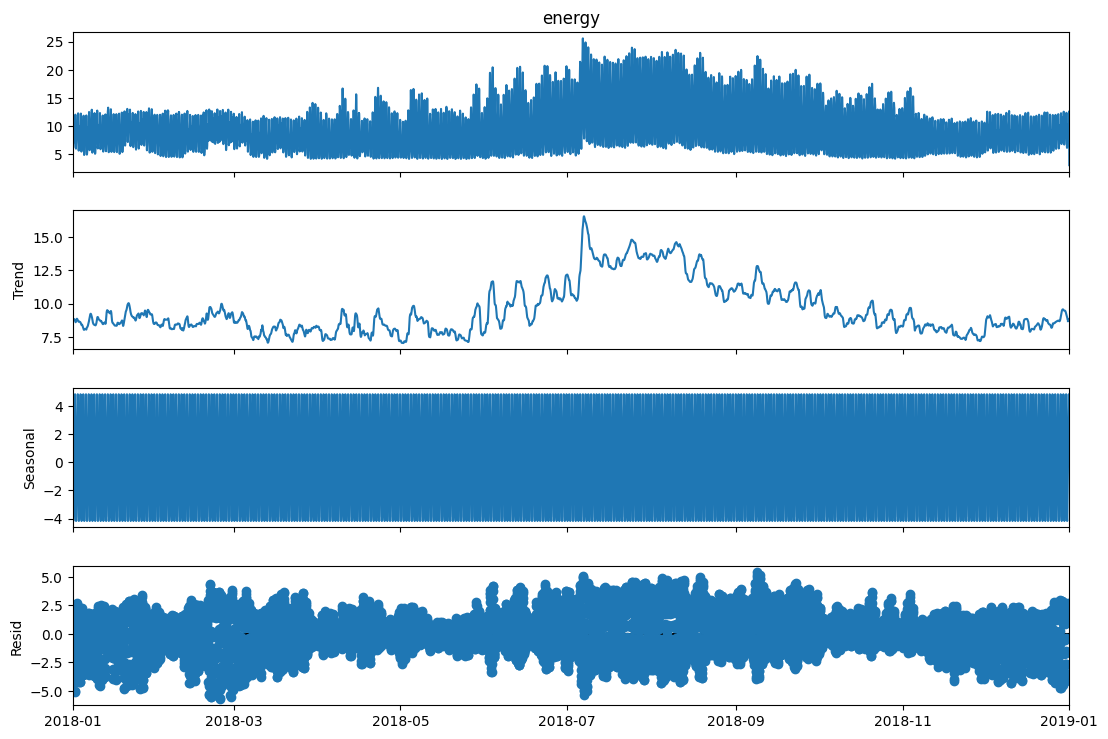

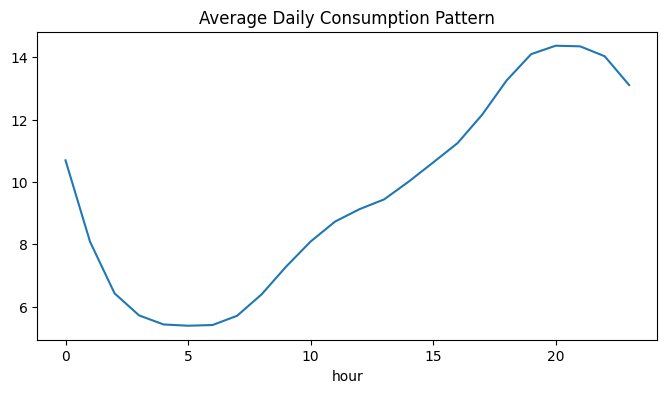

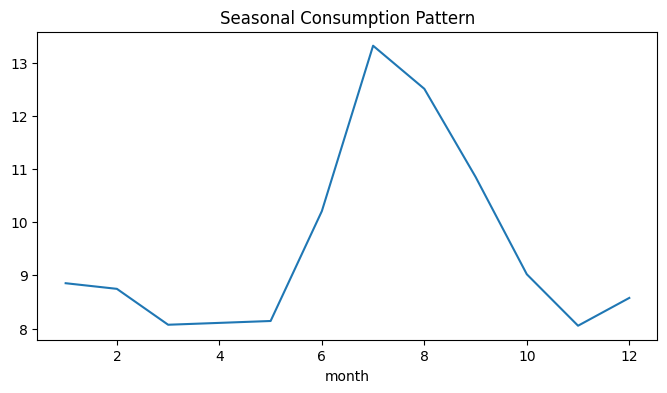

8761 hourly points
366 daily points
Hourly p-value: 0.0406
Daily p-value: 0.8234
Train: 7008 Test: 1753
Epoch 1/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0181 - val_loss: 0.0012
Epoch 2/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0043 - val_loss: 0.0012
Epoch 3/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 4/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0033 - val_loss: 0.0011
Epoch 5/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0030 - val_loss: 7.8586e-04
Epoch 6/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0027 - val_loss: 9.5485e-04
Epoch 7/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0022 - val_loss: 0.0010
Epoch 8/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0019 - val_loss: 9.0116e-04
Epoch 9/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0017 - val_loss: 8.8553e-04
Epoch 10/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0016 - val_loss: 5.7584e-04
Epoch

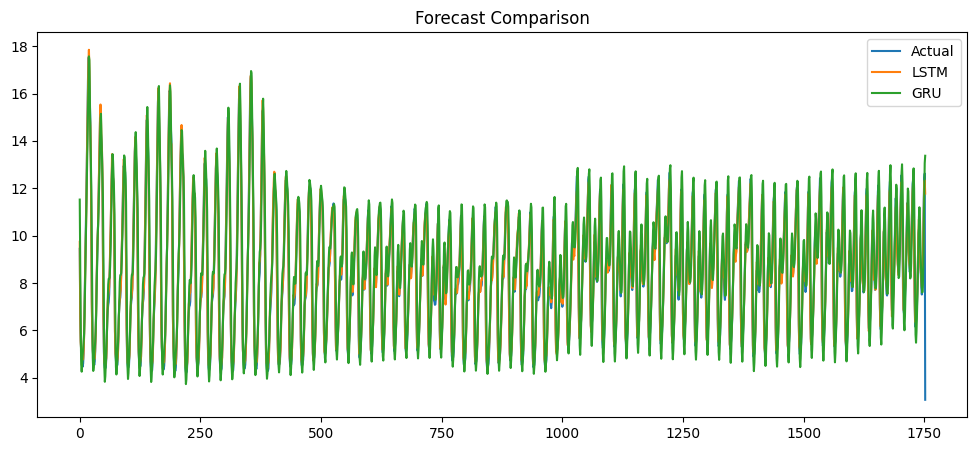

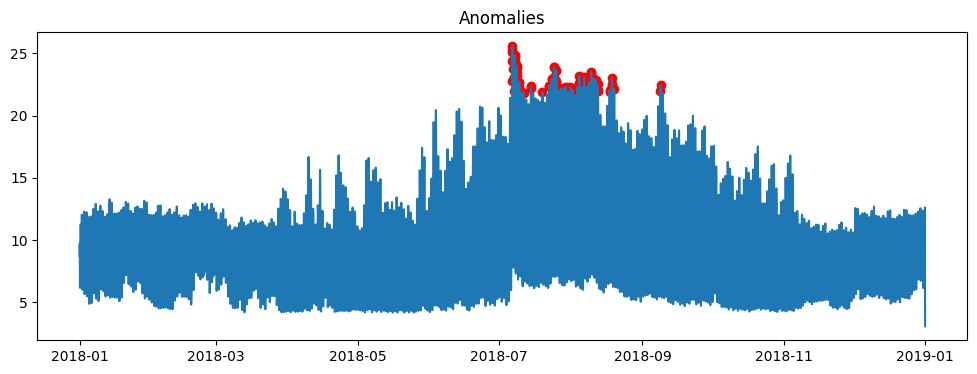

  Model       MAE      RMSE      MAPE        R2
0  LSTM  0.172979  0.298223  2.262727  0.986418
1   GRU  0.701529  1.003662  9.109936  0.846160
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

LSTM Anomaly Detection Results
----------------------------------------
Total anomalies: 1
Peak-hour anomalies: 0
Non-peak anomalies: 1

GRU Anomaly Detection Results
----------------------------------------
Total anomalies: 1
Peak-hour anomalies: 0
Non-peak anomalies: 1

LSTM Anomalies:
              actual  predicted  residual    z_score
timestamp                                           
2019-01-01  3.074109  11.779565 -8.705456 -29.280826

GRU Anomalies:
              actual  predicted   residual    z_score
timestamp                                            
2019-01-01  3.074109  13.374661 -10.300552 -10.534604
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
LSTM Peak Metrics (MAE, RMSE, MAPE, R2):
(0.18017644503736802, np.float64(0.22186979715396377), np.float64(2.286

In [22]:
# LSTM and GRU Energy Consumption Forecasting Model
#  Resolution: Hourly (resampled from 15-min)
#  Split: 80% train / 20% test (temporal)
#  Target: Per-household site energy (kWh)
# -------------------------------------------------
# 1. Import Libraries
# -------------------------------------------------
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
# Load dataset
df = pd.read_csv("up00-ca-single-family_detached.csv")
# -------------------------------------------------
# 2. Pre-Processing
# -------------------------------------------------
# Timestamp handling
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

# Target variable
col = 'out.electricity.total.energy_consumption..kwh'
df = df[[col]].rename(columns={col: 'energy'})

# Check missing timestamps
expected_range = pd.date_range(df.index.min(), df.index.max(), freq='15T')
missing = expected_range.difference(df.index)

assert len(missing) == 0
assert df.isnull().sum().sum() == 0

# Hourly (4 × 15-min)
df_hourly = df.resample('H').sum()

# Daily (24 hours)
df_daily = df_hourly.resample('D').sum()

# Scale to millions
df_hourly['energy'] /= 1e6
df_daily['energy'] /= 1e6

# Seasonal Decomposition Plots
decomposition = seasonal_decompose(df_hourly['energy'], model='additive', period=24)

fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

# Hourly pattern
df_hourly['hour'] = df_hourly.index.hour
hourly_avg = df_hourly.groupby('hour')['energy'].mean()

plt.figure(figsize=(8,4))
hourly_avg.plot(title="Average Daily Consumption Pattern")
plt.show()

# Monthly pattern
df_hourly['month'] = df_hourly.index.month
monthly_avg = df_hourly.groupby('month')['energy'].mean()

plt.figure(figsize=(8,4))
monthly_avg.plot(title="Seasonal Consumption Pattern")
plt.show()

# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_hourly[['energy']])

print(len(df_hourly), "hourly points")
print(len(df_daily), "daily points")

#ADF Test
def adf_test(series, name):
    result = adfuller(series)
    print(f"{name} p-value: {result[1]:.4f}")
    return result[1]

p_hourly = adf_test(df_hourly['energy'], "Hourly")
p_daily = adf_test(df_daily['energy'], "Daily")
# Differencing (ONLY for ARIMA-style comparison)
df_hourly_diff = df_hourly.diff().dropna()
df_daily_diff = df_daily.diff().dropna()

# -------------------------------------------------
# 3. Train - Test Split
# -------------------------------------------------
# Train
def split_series(df, ratio=0.8):
    split = int(len(df) * ratio)
    return df[:split], df[split:]
train_h, test_h = split_series(df_hourly)

print("Train:", len(train_h), "Test:", len(test_h))

scaler = MinMaxScaler()

# Fit only on training
train_scaled = scaler.fit_transform(train_h[['energy']])
test_scaled = scaler.transform(test_h[['energy']])

# Combine for sequence continuity
full_scaled = np.concatenate([train_scaled, test_scaled])
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 24  # 1 day window

X, y = create_sequences(full_scaled, SEQ_LEN)

# Split sequences aligned with original split
split = len(train_scaled) - SEQ_LEN

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
# -------------------------------------------------
# 4. Optimized Model Application
# -------------------------------------------------
#Apply LSTM Model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

lstm_model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

#Apply GRU Model
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
# -------------------------------------------------
# 5. Evaluation
# -------------------------------------------------
#Evaluate Both Models
def evaluate(model):
    preds = model.predict(X_test)

    preds = scaler.inverse_transform(preds)
    y_true = scaler.inverse_transform(y_test)

    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mape = np.mean(np.abs((y_true - preds) / y_true)) * 100
    r2 = r2_score(y_true, preds)

    return mae, rmse, mape, r2, y_true, preds

lstm_res = evaluate(lstm_model)
gru_res = evaluate(gru_model)

print("LSTM:", lstm_res[:4])
print("GRU:", gru_res[:4])

#Plot forecast
plt.figure(figsize=(12,5))

plt.plot(lstm_res[4], label="Actual")
plt.plot(lstm_res[5], label="LSTM")
plt.plot(gru_res[5], label="GRU")

plt.legend()
plt.title("Forecast Comparison")
plt.show()
# Z-score
df_hourly['z'] = (df_hourly['energy'] - df_hourly['energy'].mean()) / df_hourly['energy'].std()

anomalies = df_hourly[np.abs(df_hourly['z']) > 3]

plt.figure(figsize=(12,4))
plt.plot(df_hourly['energy'])
plt.scatter(anomalies.index, anomalies['energy'], color='red')
plt.title("Anomalies")
plt.show()
results = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MAE": [lstm_res[0], gru_res[0]],
    "RMSE": [lstm_res[1], gru_res[1]],
    "MAPE": [lstm_res[2], gru_res[2]],
    "R2": [lstm_res[3], gru_res[3]]
})

print(results)
# -------------------------------------------------
# 6. Anomaly Detection
# -------------------------------------------------

def detect_anomalies_dl(y_true, y_pred, test_index, model_name, threshold=3):
    """
    Detect anomalies using z-score of residuals.

    y_true: actual inverse-scaled values
    y_pred: predicted inverse-scaled values
    test_index: datetime index aligned with y_true/y_pred
    model_name: model label, e.g. "LSTM" or "GRU"
    threshold: z-score threshold, default = 3
    """

    # Create evaluation dataframe
    results = pd.DataFrame({
        "actual": y_true.flatten(),
        "predicted": y_pred.flatten()
    }, index=test_index)

    # Calculate residuals
    results["residual"] = results["actual"] - results["predicted"]

    # Standardize residuals using z-score
    results["z_score"] = (
        results["residual"] - results["residual"].mean()
    ) / results["residual"].std()

    # Flag anomalies
    results["anomaly"] = np.abs(results["z_score"]) > threshold

    # Identify peak-hour anomalies: 9–11 AM
    results["peak_hour"] = results.index.hour.isin([9, 10, 11])

    total_anomalies = results["anomaly"].sum()
    peak_anomalies = results[(results["anomaly"]) & (results["peak_hour"])].shape[0]

    print(f"\n{model_name} Anomaly Detection Results")
    print("-" * 40)
    print(f"Total anomalies: {total_anomalies}")
    print(f"Peak-hour anomalies: {peak_anomalies}")
    print(f"Non-peak anomalies: {total_anomalies - peak_anomalies}")

    return results

# LSTM predictions
y_pred_lstm = lstm_model.predict(X_test)
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)

# GRU predictions
y_pred_gru = gru_model.predict(X_test)
y_pred_gru_inv = scaler.inverse_transform(y_pred_gru)

# Actual values
y_test_inv = scaler.inverse_transform(y_test)

# Align timestamps with test predictions
test_index = df_hourly.index[-len(y_test_inv):]


lstm_anomaly_results = detect_anomalies_dl(
    y_true=y_test_inv,
    y_pred=y_pred_lstm_inv,
    test_index=test_index,
    model_name="LSTM"
)

gru_anomaly_results = detect_anomalies_dl(
    y_true=y_test_inv,
    y_pred=y_pred_gru_inv,
    test_index=test_index,
    model_name="GRU"
)
# Show detected LSTM anomalies
lstm_anomalies = lstm_anomaly_results[lstm_anomaly_results["anomaly"]]
print("\nLSTM Anomalies:")
print(lstm_anomalies[["actual", "predicted", "residual", "z_score"]])

# Show detected GRU anomalies
gru_anomalies = gru_anomaly_results[gru_anomaly_results["anomaly"]]
print("\nGRU Anomalies:")
print(gru_anomalies[["actual", "predicted", "residual", "z_score"]])
# -------------------------------------------------
# 7. Peak Evaluation Metrics
# -------------------------------------------------

def compute_peak_metrics(y_true, y_pred, test_index):
    """
    y_true, y_pred → numpy arrays (already inverse scaled)
    test_index → datetime index aligned with test predictions
    """

    # Create dataframe for alignment
    df_eval = pd.DataFrame({
        'actual': y_true.flatten(),
        'predicted': y_pred.flatten()
    }, index=test_index)

    # Extract peak hours (9–11 AM)
    peak_df = df_eval[df_eval.index.hour.isin([9, 10, 11])]

    # Metrics
    mae = mean_absolute_error(peak_df['actual'], peak_df['predicted'])
    rmse = np.sqrt(mean_squared_error(peak_df['actual'], peak_df['predicted']))
    mape = np.mean(np.abs((peak_df['actual'] - peak_df['predicted']) / peak_df['actual'])) * 100
    r2 = r2_score(peak_df['actual'], peak_df['predicted'])

    return mae, rmse, mape, r2
    # Recreate test index aligned with sequences
test_index = df_hourly.index[-len(y_test):]
# Inverse scaling (same as your evaluation step)
y_true_lstm = scaler.inverse_transform(y_test)
y_pred_lstm = scaler.inverse_transform(lstm_model.predict(X_test))

lstm_peak_metrics = compute_peak_metrics(
    y_true_lstm,
    y_pred_lstm,
    test_index
)

print("LSTM Peak Metrics (MAE, RMSE, MAPE, R2):")
print(lstm_peak_metrics)
y_pred_gru = scaler.inverse_transform(gru_model.predict(X_test))

gru_peak_metrics = compute_peak_metrics(
    y_true_lstm,   # same ground truth
    y_pred_gru,
    test_index
)

print("GRU Peak Metrics (MAE, RMSE, MAPE, R2):")
print(gru_peak_metrics)
def format_results(name, metrics):
    mae, rmse, mape, r2 = metrics
    print(f"{name} Peak Results:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}\n")

format_results("LSTM", lstm_peak_metrics)
format_results("GRU", gru_peak_metrics)

